<a href="https://colab.research.google.com/github/kulasekara02/Big-Data-/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.4 MB/s eta 0:00:00
Environment ready ✅  |  Outputs -> eda_outputs | Figures -> eda_outputs/figures
✅ Loaded dataset from URL
Shape: (244, 7) | Source: URL: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



=== COLUMNS ===
['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None

=== SAMPLE ROWS ===


,total_bill,tip,sex,smoker,day,time,size
24,19.82,3.18,Male,No,Sat,Dinner,2
6,8.77,2.00,Male,No,Sun,Dinner,2
153,24.55,2.00,Male,No,Sun,Dinner,4
211,25.89,5.16,Male,Yes,Sat,Dinner,4
198,13.00,2.00,Female,Yes,Thur,Lunch,2



=== MISSING VALUES PER COLUMN ===


...


-- Column: day


,count
day,
Sat,87
Sun,76
Thur,62
Fri,19



-- Column: time


,count
time,
Dinner,176
Lunch,68



Duplicate rows: 1
Dropped duplicates. New shape: (243, 7)
Saved figure -> eda_outputs/figures/hist_total_bill.png


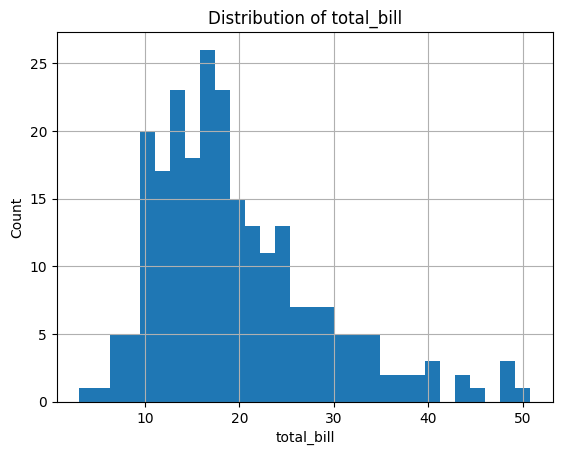

Saved figure -> eda_outputs/figures/hist_tip.png


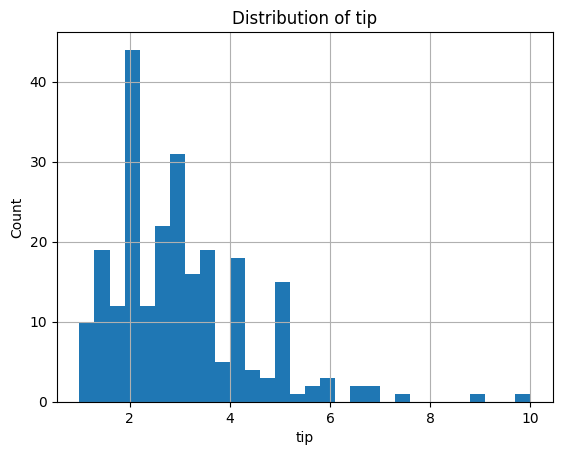

Saved figure -> eda_outputs/figures/hist_size.png


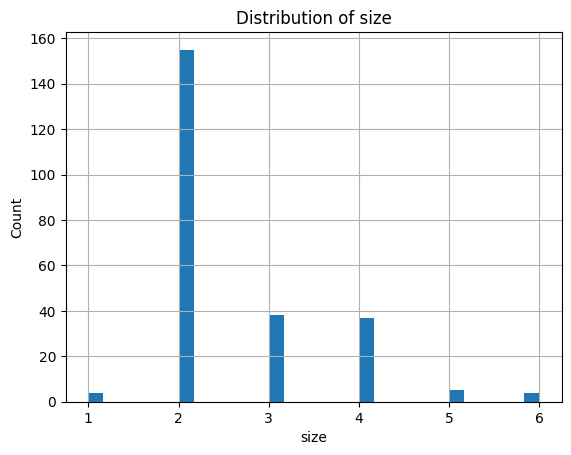

Saved figure -> eda_outputs/figures/bar_top_sex.png


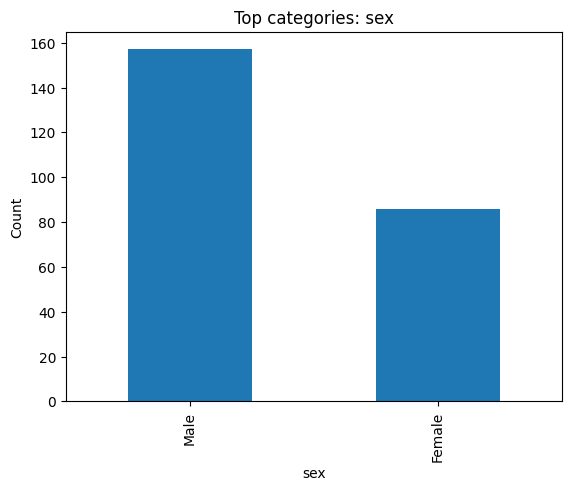

Saved figure -> eda_outputs/figures/bar_top_smoker.png


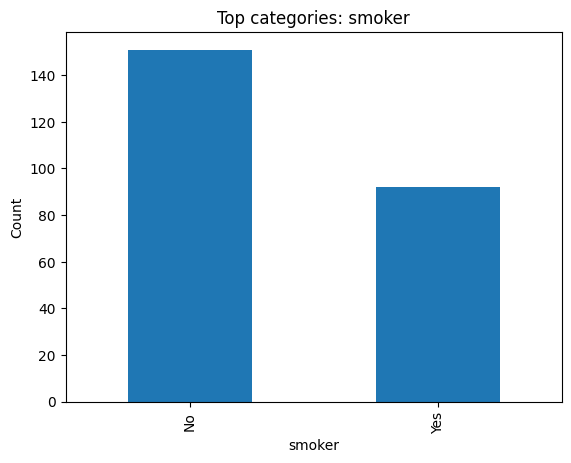

Saved figure -> eda_outputs/figures/bar_top_day.png


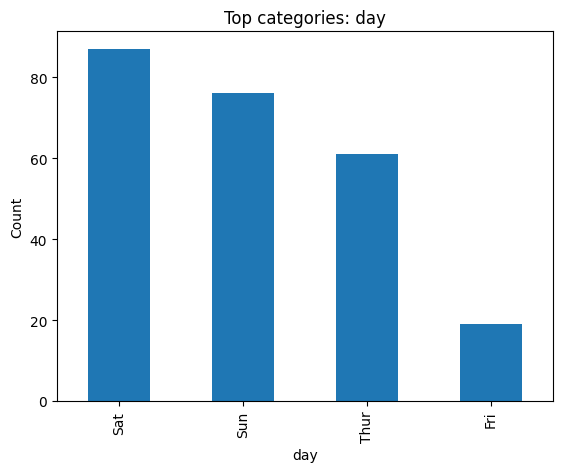

Saved figure -> eda_outputs/figures/bar_top_time.png


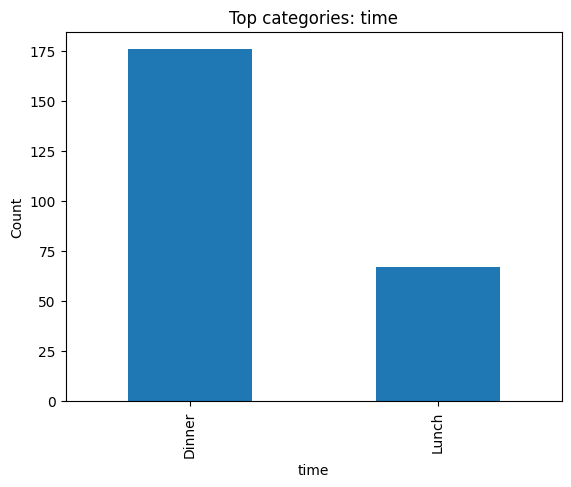

Saved figure -> eda_outputs/figures/corr_heatmap.png


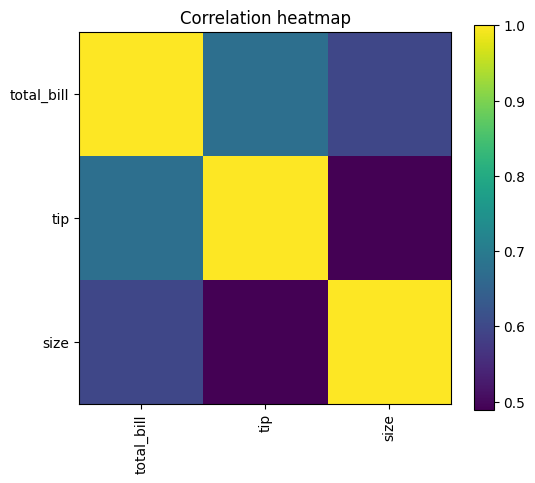

Saved figure -> eda_outputs/figures/hist_tip_pct.png


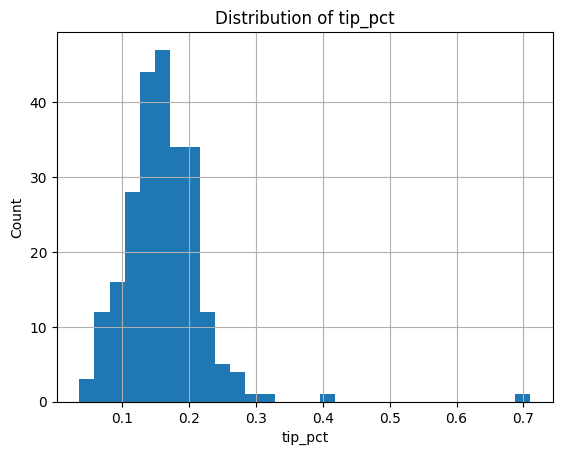

Saved figure -> eda_outputs/figures/bar_tip_pct_by_day.png


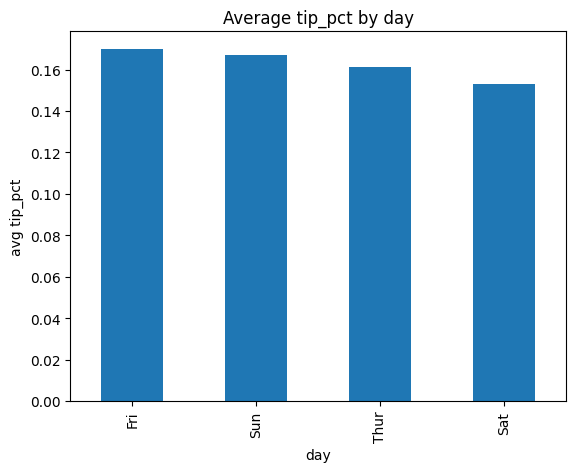

Saved figure -> eda_outputs/figures/bar_tip_pct_by_time.png


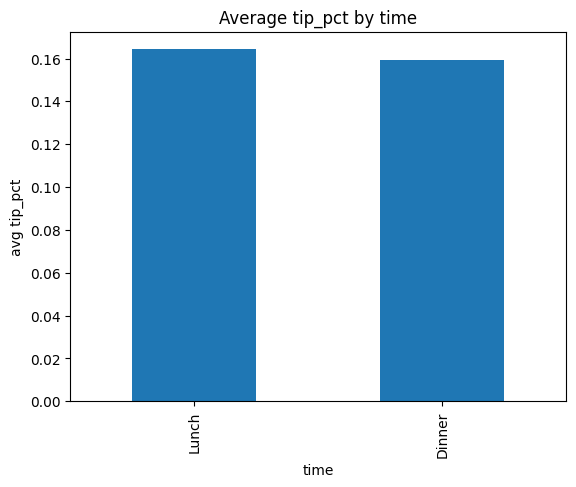

Saved figure -> eda_outputs/figures/bar_tip_pct_by_size.png


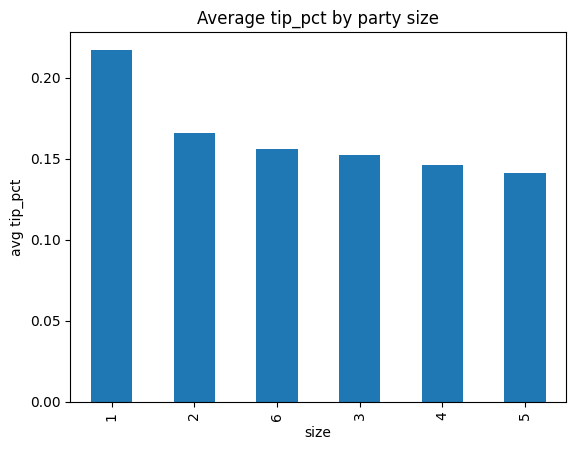


Domain notes:
 - Median tip_pct: 0.155
 - Top day by avg tip_pct: Fri = 0.170
 - Top time by avg tip_pct: Lunch = 0.164
 - Top party size by avg tip_pct: 1 = 0.217

BUSINESS MODEL (Example): Tipping Optimization & Staffing Insights
------------------------------------------------------------------
Context:
- Imagine a food-delivery marketplace or POS provider that onboards restaurants.
- We want to understand tipping behavior to improve revenue and customer/staff satisfaction.

Primary Objectives:
1) Identify when/where tipping is strongest (day, time, party size).
2) Quantify how ticket size relates to tipping (tip_pct vs total_bill).
3) Provide staffing & promo recommendations (e.g., focus on high-tipping windows).

Stakeholders:
- Restaurant managers (pricing, staffing, promotions).
- Finance/ops (revenue forecasting).
- Customer success (service quality improvements).

Potential Data Product:
- A lightweight dashboard highlighting tip_pct distributions, best days/times, and expect

In [1]:
# ==============================
# PROJECT: OWN DATA PRODUCT — OBJECTIVES ASSESSMENT & ANALYSIS
# Domain Example: Restaurant Analytics (Tipping Optimization & Staffing Insights)
# Google Colab READY (no seaborn)
# ==============================

# ---- 0) ENVIRONMENT SETUP ----
!pip install -q pandas numpy matplotlib reportlab

import os, math, json, textwrap, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Folders for outputs
OUT_DIR = "eda_outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

TODAY = datetime.date.today().isoformat()
print("Environment ready ✅  |  Outputs ->", OUT_DIR, "| Figures ->", FIG_DIR)

# ---- 1) LOAD DATA ----
# 1.A DEFAULT: use a stable public CSV (restaurant "tips" dataset)
#    You can SWITCH to your own dataset by using 1.B below.
DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

df = None
source = None

try:
    df = pd.read_csv(DATA_URL)
    source = f"URL: {DATA_URL}"
    print("✅ Loaded dataset from URL")
except Exception as e:
    print("⚠️ Could not read from URL:", e)

# 1.B UPLOAD (if URL didn't work or you want to use your file)
if df is None:
    print("\nUpload a CSV file from your computer...")
    try:
        from google.colab import files
        uploaded = files.upload()   # pick your CSV
        local_name = list(uploaded.keys())[0]
        df = pd.read_csv(local_name)
        source = f"Local file: {local_name}"
        print("✅ Loaded dataset from upload")
    except Exception as e:
        raise SystemExit("No dataframe loaded. Please rerun and upload a CSV.") from e

print("Shape:", df.shape, "| Source:", source)
display(df.head())

# ---- 2) QUICK DATA OVERVIEW ----
print("\n=== COLUMNS ===")
print(list(df.columns))

print("\n=== INFO ===")
print(df.info())

print("\n=== SAMPLE ROWS ===")
display(df.sample(min(5, len(df)), random_state=42))

print("\n=== MISSING VALUES PER COLUMN ===")
na_counts = df.isna().sum().sort_values(ascending=False)
na_tbl = pd.DataFrame({"missing": na_counts, "missing_pct": (na_counts/len(df))*100})
display(na_tbl.style.format({"missing_pct": "{:.2f}%"}))

print("\n=== BASIC NUMERIC SUMMARY ===")
display(df.describe().T)

print("\n=== BASIC CATEGORICAL SUMMARY (Top 10) ===")
cat_cols = [c for c in df.columns if df[c].dtype == "object"]
for c in cat_cols[:10]:
    print(f"\n-- Column: {c}")
    display(df[c].value_counts(dropna=False).head(10))

# ---- 3) LIGHT CLEANING ----
# 3.1 Strip whitespace on strings
for c in df.select_dtypes(include="object"):
    df[c] = df[c].astype(str).str.strip()

# 3.2 Report duplicates and (optionally) drop
dups = df.duplicated().sum()
print(f"\nDuplicate rows: {dups}")
if dups > 0:
    df = df.drop_duplicates()
    print("Dropped duplicates. New shape:", df.shape)

# (Optional) Numeric coercion example (uncomment and adapt)
# for c in ["price", "amount"]:   # replace with your actual numeric-looking cols
#     if c in df.columns:
#         df[c] = pd.to_numeric(df[c], errors="coerce")

# ---- 4) EXPLORATORY VISUALIZATIONS (matplotlib only) ----
def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, bbox_inches="tight")
    print("Saved figure ->", path)

# 4.1 Histograms (up to 12 numeric features)
num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
for c in num_cols[:12]:
    plt.figure()
    df[c].dropna().hist(bins=30)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c); plt.ylabel("Count")
    savefig(f"hist_{c}.png")
    plt.show()

# 4.2 Bar charts (top 10 categories for up to 6 categorical cols)
for c in cat_cols[:6]:
    vc = df[c].value_counts().head(10)
    plt.figure()
    vc.plot(kind="bar")
    plt.title(f"Top categories: {c}")
    plt.xlabel(c); plt.ylabel("Count")
    savefig(f"bar_top_{c}.png")
    plt.show()

# 4.3 Correlation heatmap (if >=2 numeric cols)
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(6,5))
    plt.imshow(corr, interpolation="nearest")
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.title("Correlation heatmap")
    plt.colorbar()
    savefig("corr_heatmap.png")
    plt.show()

# ---- 5) DOMAIN-SPECIFIC METRICS (tips dataset example) ----
# If you use your own dataset, adapt this section to your business domain.
domain_notes = []
if set(["total_bill", "tip"]).issubset(df.columns):
    # Create tip percentage
    df["tip_pct"] = df["tip"] / df["total_bill"]
    # Basic aggregates
    tip_stats = df["tip_pct"].describe(percentiles=[0.25,0.5,0.75]).to_dict()
    avg_by_day = df.groupby("day")["tip_pct"].mean().sort_values(ascending=False)
    avg_by_time = df.groupby("time")["tip_pct"].mean().sort_values(ascending=False) if "time" in df.columns else None
    avg_by_size = df.groupby("size")["tip_pct"].mean().sort_values(ascending=False) if "size" in df.columns else None

    # Plot tip_pct distributions and group bars
    plt.figure()
    df["tip_pct"].dropna().hist(bins=30)
    plt.title("Distribution of tip_pct")
    plt.xlabel("tip_pct"); plt.ylabel("Count")
    savefig("hist_tip_pct.png")
    plt.show()

    plt.figure()
    avg_by_day.plot(kind="bar")
    plt.title("Average tip_pct by day")
    plt.xlabel("day"); plt.ylabel("avg tip_pct")
    savefig("bar_tip_pct_by_day.png")
    plt.show()

    if avg_by_time is not None:
        plt.figure()
        avg_by_time.plot(kind="bar")
        plt.title("Average tip_pct by time")
        plt.xlabel("time"); plt.ylabel("avg tip_pct")
        savefig("bar_tip_pct_by_time.png")
        plt.show()

    if avg_by_size is not None:
        plt.figure()
        avg_by_size.plot(kind="bar")
        plt.title("Average tip_pct by party size")
        plt.xlabel("size"); plt.ylabel("avg tip_pct")
        savefig("bar_tip_pct_by_size.png")
        plt.show()

    # Correlation between numeric features incl. tip_pct
    if "tip_pct" not in num_cols:
        num_cols.append("tip_pct")
    corr2 = df[num_cols].corr(numeric_only=True)

    # Summarize key numbers for business write-up
    domain_notes.append(f"Median tip_pct: {tip_stats.get('50%', float('nan')):.3f}")
    domain_notes.append(f"Top day by avg tip_pct: {avg_by_day.index[0]} = {avg_by_day.iloc[0]:.3f}")
    if avg_by_time is not None:
        domain_notes.append(f"Top time by avg tip_pct: {avg_by_time.index[0]} = {avg_by_time.iloc[0]:.3f}")
    if avg_by_size is not None:
        domain_notes.append(f"Top party size by avg tip_pct: {avg_by_size.index[0]} = {avg_by_size.iloc[0]:.3f}")

else:
    domain_notes.append("Custom domain metrics not computed: expected columns ['total_bill','tip'] not found. Adapt Section 5 for your dataset.")

print("\nDomain notes:")
for n in domain_notes:
    print(" -", n)

# ---- 6) OBJECTIVE FRAMING & NARRATIVE (editable text) ----
business_model_text = """
BUSINESS MODEL (Example): Tipping Optimization & Staffing Insights
------------------------------------------------------------------
Context:
- Imagine a food-delivery marketplace or POS provider that onboards restaurants.
- We want to understand tipping behavior to improve revenue and customer/staff satisfaction.

Primary Objectives:
1) Identify when/where tipping is strongest (day, time, party size).
2) Quantify how ticket size relates to tipping (tip_pct vs total_bill).
3) Provide staffing & promo recommendations (e.g., focus on high-tipping windows).

Stakeholders:
- Restaurant managers (pricing, staffing, promotions).
- Finance/ops (revenue forecasting).
- Customer success (service quality improvements).

Potential Data Product:
- A lightweight dashboard highlighting tip_pct distributions, best days/times, and expected uplift from staffing/promos.

Limitations & Risks:
- Dataset is small and from one context (not universal).
- No causal claims; only correlations and descriptive patterns.
- Biases (who dines where, etc.). Need more features (weather, location density, campaign flags).
"""

print(business_model_text)

# ---- 7) AUTO SUMMARY FILES (Markdown + PDF) ----
summary_md = f"""
# Dataset EDA Summary
**Generated:** {TODAY}
**Source:** {source}

## Shape
Rows: {len(df)} | Columns: {len(df.columns)}

## Columns
- {', '.join(map(str, df.columns))}

## Missingness (Top 10)
{df.isna().sum().sort_values(ascending=False).head(10).to_string()}

## Key Numeric Snapshot
{df.describe().T.to_string(max_cols=8)}

## Business Model (excerpt)
Tipping Optimization & Staffing Insights:
- Discover high-tipping windows and segments
- Inform staffing and promotions
- Caveat: descriptive, not causal

## Domain Notes
- {'; '.join(domain_notes) if domain_notes else 'N/A'}

See figures in `eda_outputs/figures/` and notebook sections for details.
"""
os.makedirs(OUT_DIR, exist_ok=True)
with open(os.path.join(OUT_DIR, "eda_summary_auto.md"), "w", encoding="utf-8") as f:
    f.write(summary_md)
print("Wrote:", os.path.join(OUT_DIR, "eda_summary_auto.md"))

# Build a concise PDF (1–2 pages) with key points
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.units import cm

pdf_path = os.path.join(OUT_DIR, "own_data_product_summary.pdf")
c = canvas.Canvas(pdf_path, pagesize=A4)
width, height = A4

def add_heading(text, y):
    c.setFont("Helvetica-Bold", 15)
    c.drawString(2*cm, y, text)

def add_para(text, y_start, leading=13):
    c.setFont("Helvetica", 10.5)
    y = y_start
    for line in textwrap.wrap(text, width=92):
        c.drawString(2*cm, y, line)
        y -= leading
    return y

y = height - 2*cm
add_heading("Project: Own Data Product — Objectives Assessment & Analysis", y); y -= 1.0*cm
c.setFont("Helvetica", 9.5); c.drawString(2*cm, y, f"Generated on {TODAY} | Source: {source}"); y -= 0.8*cm

add_heading("1) Dataset & Problem Context", y); y -= 0.6*cm
y = add_para("Domain: Restaurant analytics. Goal: understand tipping behavior to inform staffing and promotions.", y)

y -= 0.3*cm
add_heading("2) Objectives", y); y -= 0.6*cm
y = add_para("Identify high-tipping windows (day/time/party size). Relate ticket size to tipping rate. Provide actionable insights to managers.", y)

y -= 0.3*cm
add_heading("3) Data Description", y); y -= 0.6*cm
y = add_para(f"Rows: {len(df)}; Columns: {len(df.columns)}. Key fields include: {', '.join(df.columns[:8])}{'...' if len(df.columns)>8 else ''}.", y)

y -= 0.3*cm
add_heading("4) Key Insights (EDA)", y); y -= 0.6*cm
eda_points = []
eda_points.append("Distributions and correlation heatmap prepared (see figures).")
if 'tip_pct' in df.columns:
    eda_points.append("Created tip_pct = tip / total_bill to standardize tipping.")
for n in domain_notes:
    eda_points.append(n)
y = add_para(" ; ".join(eda_points), y)

y -= 0.3*cm
add_heading("5) Potential Use Cases", y); y -= 0.6*cm
y = add_para("Shift planning; promo timing; expected uplift calculator; partner onboarding insights.", y)

y -= 0.3*cm
add_heading("6) Limitations & Risks", y); y -= 0.6*cm
y = add_para("Small sample, single context; descriptive only; possible selection and recording bias; needs more features for decisions.", y)

y -= 0.3*cm
add_heading("7) Next Steps", y); y -= 0.6*cm
y = add_para("Ingest larger, multi-location data; add weather & campaign flags; define KPI thresholds; build a minimal dashboard.", y)

c.showPage()
c.save()

print("📄 PDF written ->", pdf_path)

print("\n✅ All done. Download your files from the left file panel:")
print(" - eda_outputs/own_data_product_summary.pdf")
print(" - eda_outputs/eda_summary_auto.md")
print(" - eda_outputs/figures/*.png")
